<h1 style="font-size: 48px; font-weight: bold;">
1. Peak Modeling
</h1>

<h2 style="font-weight: bold; font-size: 28px;">
1.1 Data Loading
</h2>

In [19]:
import pandas as pd

feat_28 = pd.read_csv("py_data/peak_feat_28.csv")
measurements = pd.read_csv("py_data/peak_measurements.csv")

<h2 style="font-weight: bold; font-size: 28px;">
1.2 Name Mapping
</h2>

In [20]:
name_map = {
    "slope_log": "log_slope",
    "slope_y_1_7": "short_slopes",
    "longest_inc_run": "inc_run",
    "zero_count": "nonzero_days",

    "c22_DN_HistogramMode_5": "mode_5",
    "c22_DN_HistogramMode_10": "mode_10",
    "c22_CO_f1ecac": "acf_timescale",
    "c22_CO_FirstMin_ac": "acf_first_min",
    "c22_CO_HistogramAMI_even_2_5": "ami2",
    "c22_CO_trev_1_num": "trev",
    "c22_MD_hrv_classic_pnn40": "high_fluctuation",
    "c22_SB_BinaryStats_mean_longstretch1": "stretch_high",
    "c22_SB_TransitionMatrix_3ac_sumdiagcov": "transition_variance",
    "c22_PD_PeriodicityWang_th0_01": "periodicity",
    "c22_CO_Embed2_Dist_tau_d_expfit_meandiff": "embedding_dist",
    "c22_IN_AutoMutualInfoStats_40_gaussian_fmmi": "ami_timescale",
    "c22_FC_LocalSimple_mean1_tauresrat": "whiten_timescale",
    "c22_DN_OutlierInclude_p_001_mdrmd": "outlier_timing_pos",
    "c22_DN_OutlierInclude_n_001_mdrmd": "outlier_timing_neg",
    "c22_SP_Summaries_welch_rect_area_5_1": "low_freq_power",
    "c22_SB_BinaryStats_diff_longstretch0": "stretch_decreasing",
    "c22_SB_MotifThree_quantile_hh": "entropy_pairs",
    "c22_SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1": "rs_range",
    "c22_SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1": "dfa",
    "c22_SP_Summaries_welch_rect_centroid": "centroid_freq",
    "c22_FC_LocalSimple_mean3_stderr": "forecast_error"
}

feat_28 = feat_28.rename(columns={k: v for k, v in name_map.items() if k in feat_28.columns})
feat_28.columns

Index(['country', 'lineage', 'log_slope', 'short_slopes', 'peak_val',
       'auc_norm', 'inc_run', 'nonzero_days', 'mode_5', 'mode_10',
       'acf_timescale', 'acf_first_min', 'ami2', 'trev', 'high_fluctuation',
       'stretch_high', 'transition_variance', 'periodicity', 'embedding_dist',
       'ami_timescale', 'whiten_timescale', 'outlier_timing_pos',
       'outlier_timing_neg', 'low_freq_power', 'stretch_decreasing',
       'entropy_pairs', 'rs_range', 'dfa', 'centroid_freq', 'forecast_error'],
      dtype='object')

<h2 style="font-weight: bold; font-size: 28px;">
1.3 Data Merging
</h2>

In [27]:
df = feat_28.drop(columns=["auc_norm"]).merge(
    measurements[["country", "lineage", "peak_share_cat"]],
    on=["country", "lineage"],
    how="left"
)

<h2 style="font-weight: bold; font-size: 28px;">
1.4 Modeling Training
</h2>

In [29]:
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# --------------------------
# 1. Prepare data
# --------------------------

# response
y = df["peak_share_cat"]

# encode categorical response to numeric labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# features — drop non-feature columns
X = df.drop(columns=["country", "lineage", "peak_share_cat"])

# train-test split (stratified for class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=123,
    stratify=y_encoded
)

# DMatrix for XGBoost
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest  = xgb.DMatrix(X_test, label=y_test)

# --------------------------
# 2. Define XGBoost parameters (with pruning)
# --------------------------

params = {
    "objective": "multi:softprob",   # multi-class classification
    "num_class": 3,                  # three classes
    "eval_metric": "mlogloss",       
    
    # ----- pruning & regularization -----
    "max_depth": 4,          # smaller depth → more pruning
    "min_child_weight": 3,   # minimum samples needed to split
    "gamma": 0.5,            # pruning strength
    "lambda": 2.0,           # L2 regularization
    "alpha": 1.0,            # L1 regularization
    
    # ----- tree method -----
    "eta": 0.1,              # learning rate
    "subsample": 0.8,
    "colsample_bytree": 0.8,
}

# --------------------------
# 3. Train model with early stopping
# --------------------------

evallist = [(dtrain, "train"), (dtest, "eval")]

bst = xgb.train(
    params,
    dtrain,
    num_boost_round=500,
    evals=evallist,
    early_stopping_rounds=30,
    verbose_eval=20
)

# --------------------------
# 4. Predictions & evaluation
# --------------------------

# predict probabilities
pred_prob = bst.predict(dtest)

# convert softprob → single class
pred_label = np.argmax(pred_prob, axis=1)

# original labels back
y_true = le.inverse_transform(y_test)
y_pred = le.inverse_transform(pred_label)

print("Classification Report:")
print(classification_report(y_true, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

[0]	train-mlogloss:1.07189	eval-mlogloss:1.08042


[20]	train-mlogloss:0.77609	eval-mlogloss:0.95992
[40]	train-mlogloss:0.65530	eval-mlogloss:0.95632
[59]	train-mlogloss:0.57837	eval-mlogloss:0.96151
Classification Report:
              precision    recall  f1-score   support

   0.10–0.20       0.48      0.59      0.53        96
       <0.10       0.49      0.57      0.52        60
       >0.20       0.54      0.16      0.24        45

    accuracy                           0.49       201
   macro avg       0.50      0.44      0.43       201
weighted avg       0.50      0.49      0.46       201

Confusion Matrix:
[[57 34  5]
 [25 34  1]
 [36  2  7]]


<h2 style="font-weight: bold; font-size: 28px;">
1.5 SHAP Analysis I
</h2>

In [ ]:
import shap
import matplotlib.pyplot as plt
explainer = shap.Explainer(bst, X_train)
shap_values = explainer(X_train)

In [44]:
plt.figure(figsize=(10, 8))

# important: show=False makes it draw on the matplotlib figure
shap.plots.beeswarm(shap_values[:, :, 2], max_display=15, show=False)

plt.tight_layout()
plt.savefig("../result/plots2/shap_beeswarm_peak.png", dpi=300)
plt.close()

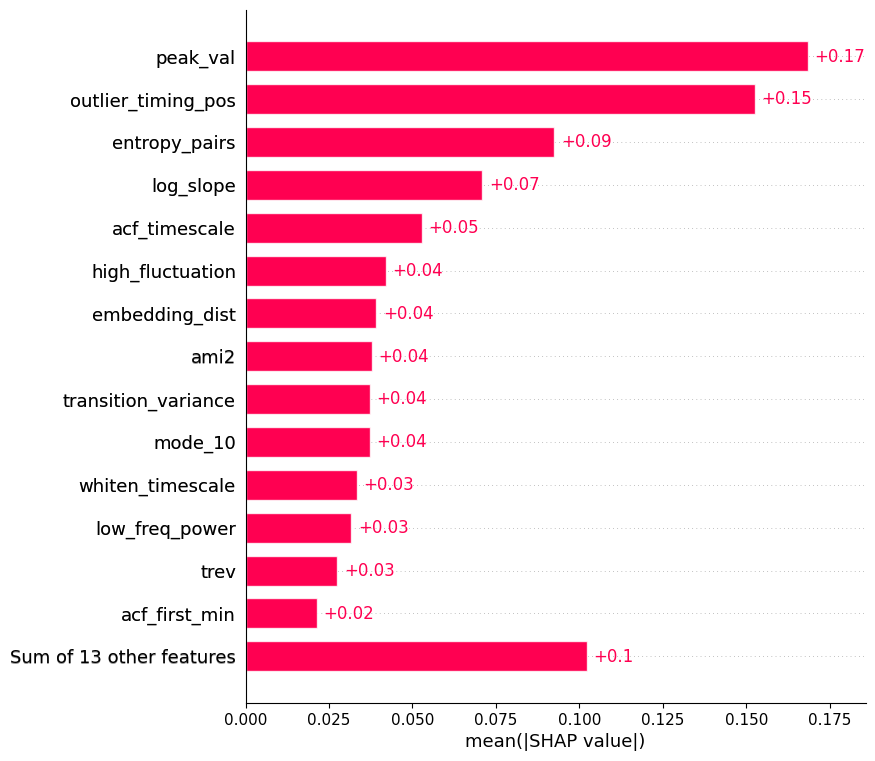

In [46]:
shap.plots.bar(shap_values[:, :, 2], max_display=15)

plt.figure(figsize=(10, 8))

# important: show=False makes it draw on the matplotlib figure
shap.plots.bar(shap_values[:, :, 2], max_display=15, show=False)

plt.tight_layout()
plt.savefig("../result/plots2/shap_values_peak.png", dpi=300)
plt.close()

<h1 style="font-size: 48px; font-weight: bold;">
2. Duration Modeling
</h1>

<h2 style="font-weight: bold; font-size: 28px;">
2.1 Data Loading
</h2>

In [48]:
feat_21 = pd.read_csv("py_data/duration_feat_21.csv")
measurements = pd.read_csv("py_data/duration_measurements.csv")

In [49]:
feat_21 = feat_21.rename(columns={k: v for k, v in name_map.items() if k in feat_21.columns})
feat_21.columns

Index(['country', 'lineage', 'log_slope', 'short_slopes', 'peak_val',
       'auc_norm', 'inc_run', 'nonzero_days', 'mode_5', 'mode_10',
       'acf_timescale', 'acf_first_min', 'ami2', 'trev', 'high_fluctuation',
       'stretch_high', 'transition_variance', 'periodicity', 'embedding_dist',
       'ami_timescale', 'whiten_timescale', 'outlier_timing_pos',
       'outlier_timing_neg', 'low_freq_power', 'stretch_decreasing',
       'entropy_pairs', 'rs_range', 'dfa', 'centroid_freq', 'forecast_error'],
      dtype='object')

<h2 style="font-weight: bold; font-size: 28px;">
2.2 Data Merging
</h2>

In [59]:
df = feat_21.drop(columns=["auc_norm"]).merge(
    measurements[["country", "lineage", "days_above_10_cat"]],
    on=["country", "lineage"],
    how="left"
)
df = df.dropna(subset=["days_above_10_cat"])

<h2 style="font-weight: bold; font-size: 28px;">
2.3 Modeling Training
</h2>

In [62]:
# --------------------------
# 1. Prepare data
# --------------------------

# response
y = df["days_above_10_cat"]

# encode categorical response to numeric labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# features — drop non-feature columns
X = df.drop(columns=["country", "lineage", "days_above_10_cat"])

# train-test split (stratified for class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=123,
    stratify=y_encoded
)

# DMatrix for XGBoost
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest  = xgb.DMatrix(X_test, label=y_test)

# --------------------------
# 2. Define XGBoost parameters (with pruning)
# --------------------------

params = {
    "objective": "multi:softprob",   # multi-class classification
    "num_class": 3,                  # three classes
    "eval_metric": "mlogloss",       
    
    # ----- pruning & regularization -----
    "max_depth": 4,          # smaller depth → more pruning
    "min_child_weight": 3,   # minimum samples needed to split
    "gamma": 0.5,            # pruning strength
    "lambda": 2.0,           # L2 regularization
    "alpha": 1.0,            # L1 regularization
    
    # ----- tree method -----
    "eta": 0.1,              # learning rate
    "subsample": 0.8,
    "colsample_bytree": 0.8,
}

# --------------------------
# 3. Train model with early stopping
# --------------------------

evallist = [(dtrain, "train"), (dtest, "eval")]

bst = xgb.train(
    params,
    dtrain,
    num_boost_round=500,
    evals=evallist,
    early_stopping_rounds=30,
    verbose_eval=20
)

# --------------------------
# 4. Predictions & evaluation
# --------------------------

# predict probabilities
pred_prob = bst.predict(dtest)

# convert softprob → single class
pred_label = np.argmax(pred_prob, axis=1)

# original labels back
y_true = le.inverse_transform(y_test)
y_pred = le.inverse_transform(pred_label)

[0]	train-mlogloss:1.07885	eval-mlogloss:1.09185
[20]	train-mlogloss:0.84884	eval-mlogloss:1.03985
[40]	train-mlogloss:0.73663	eval-mlogloss:1.04805
[50]	train-mlogloss:0.69340	eval-mlogloss:1.04794


<h2 style="font-weight: bold; font-size: 28px;">
2.4 SHAP Analysis II
</h2>

In [63]:
explainer = shap.Explainer(bst, X_train)
shap_values = explainer(X_train)

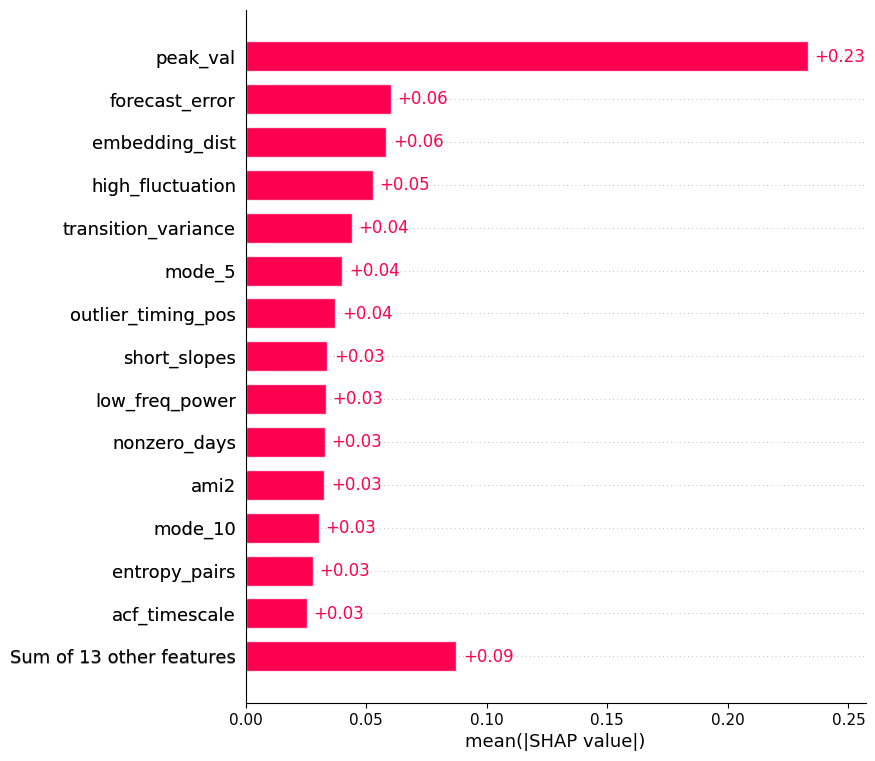

In [64]:
shap.plots.bar(shap_values[:, :, 2], max_display=15)

plt.figure(figsize=(10, 8))

# important: show=False makes it draw on the matplotlib figure
shap.plots.bar(shap_values[:, :, 2], max_display=15, show=False)

plt.tight_layout()
plt.savefig("../result/plots2/shap_values_duration.png", dpi=300)
plt.close()

In [65]:
plt.figure(figsize=(10, 8))

# important: show=False makes it draw on the matplotlib figure
shap.plots.beeswarm(shap_values[:, :, 2], max_display=15, show=False)

plt.tight_layout()
plt.savefig("../result/plots2/shap_beeswarm_duration.png", dpi=300)
plt.close()